# Customer Churn Prediction & Retention Strategy
### Author: Virinchi Kopparam

---

## Business Problem

A European bank is losing roughly 20% of its customers every year to churn. The challenge is not just measuring that number but predicting which customers are about to leave early enough to do something about it.

**Why this matters in dollars:**
- Industry average acquisition cost to replace a churned customer: $243
- At 2,037 churned customers in this dataset, that is $494,991 in replacement cost alone
- That figure does not include lost revenue from deposits, fees, or cross-sell opportunities

**What this project does:**
1. Identifies the behavioral and demographic signals that predict churn
2. Benchmarks 5 classification models to find the most reliable predictor
3. Quantifies the business cost of model errors
4. Connects model output to an actionable retention framework

**Important framing:** In churn modeling, a false negative (predicting someone stays when they actually leave) is more expensive than a false positive (flagging someone as at-risk when they are not). A false negative means a lost customer plus $243 to replace them. A false positive means an unnecessary retention offer. Model selection here prioritizes minimizing false negatives over raw accuracy.


## 1. Imports and Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

# Define the explicit project folder path
project_visuals_dir = r'C:\Users\virin\Desktop\Projects\churn_prediction_model\visuals'
os.makedirs(project_visuals_dir, exist_ok=True)

## 2. Data Loading and Validation

The dataset contains 10,000 bank customers across France, Germany, and Spain with 14 features covering demographics, account behavior, and a binary churn flag (Exited).

Columns dropped before modeling: RowNumber, CustomerId, and Surname are identifiers with no predictive value. Keeping them would not improve the model and would make it non-generalizable to new customers.


In [3]:
df = pd.read_csv(r'C:\Users\virin\Desktop\Projects\churn_prediction_model\Churn_Modelling.csv')
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [5]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Zero nulls across all columns. Dataset is clean and ready for analysis.

Quick class distribution check before going further:

In [6]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100
print(f"Retained: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"Churned:  {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")
print(f"Class imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1")

Retained: 7,963 (79.6%)
Churned:  2,037 (20.4%)
Class imbalance ratio: 3.9:1


The dataset has a roughly 4:1 class imbalance (80% retained, 20% churned). This is why SVM and Logistic Regression struggle later: they optimize for the majority class. It also explains why accuracy alone is a misleading metric here. A model that predicted nobody churns would score 80% accuracy while being completely useless.

## 3. Exploratory Data Analysis

Goal here is not just to describe the data but to find the signals that matter for retention decisions. Each chart is followed by a business interpretation.


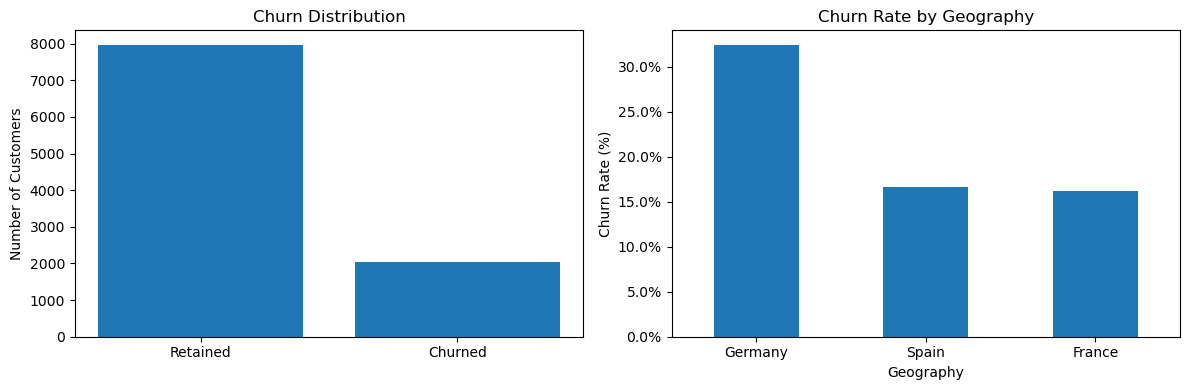

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn distribution
axes[0].bar(['Retained', 'Churned'], df['Exited'].value_counts().values)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Number of Customers')

# Churn rate by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Geography')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(project_visuals_dir, 'churn_overview.png'))
plt.show()

Germany churns at nearly double the rate of France and Spain (roughly 32% vs 16%). This is the single strongest geographic signal in the dataset and is consistent with the SQL analysis in this project.

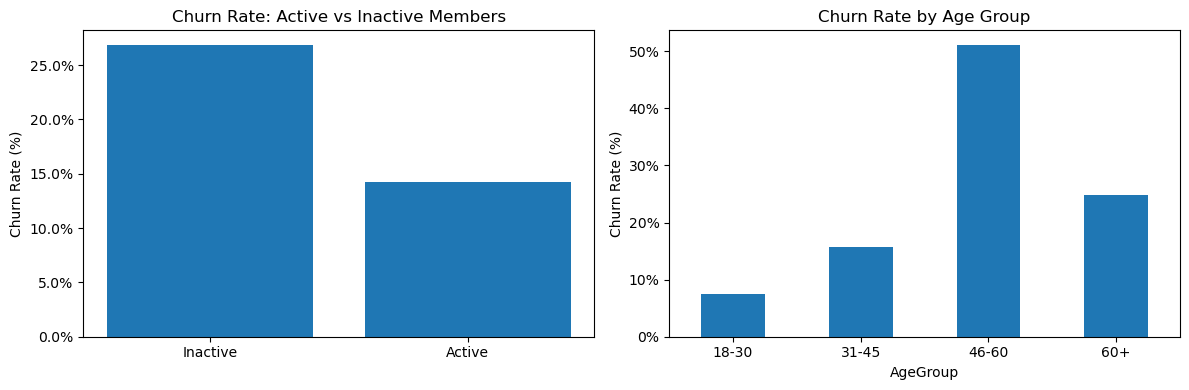

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn rate by Activity Status
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
axes[0].bar(['Inactive', 'Active'], active_churn.values)
axes[0].set_title('Churn Rate: Active vs Inactive Members')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Churn rate by Age Group
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+'])
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
age_churn.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Age Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(project_visuals_dir, 'churn_by_segment.png'))
plt.show()

df.drop(columns=['AgeGroup'], inplace=True)

Inactive members churn at roughly 2.6x the rate of active members. This is the strongest single behavioral signal in the dataset and drives the highest weight in the rules-based risk score built in the SQL companion file.

The 46-60 age band churns at the highest rate. Customers in this range tend to have higher balances and are more likely to evaluate competing products, making them both the highest risk and the most valuable to retain.

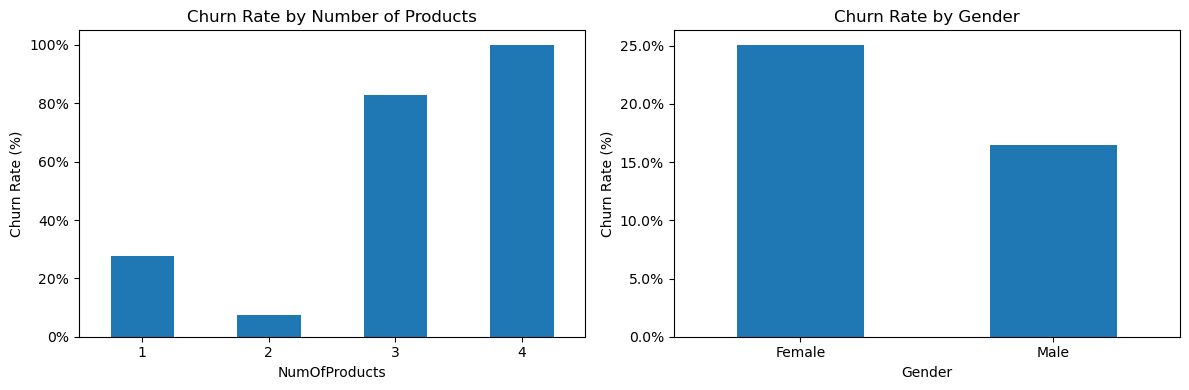

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn rate by Number of Products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Churn Rate by Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Churn rate by Gender
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(project_visuals_dir, 'churn_by_products_gender.png'))
plt.show()

Customers with 1 product churn at roughly 28%. Customers with 2 products drop to roughly 8%. That 20-point difference makes cross-sell one of the highest-ROI retention strategies available. Customers with 3 or 4 products churn at extreme rates but sample sizes are small; see SQL analysis Q6 for the full segment breakdown.

Female customers churn at a noticeably higher rate than male customers (roughly 25% vs 16%). Combined with the Germany finding, German female customers aged 46-60 are the highest-risk demographic segment in the dataset.

## 4. Preprocessing: Encoding and Feature Selection

Two encoding strategies used:
- Label encoding for Gender (binary: Male/Female becomes 0/1)
- One-hot encoding for Geography (3 categories become 2 binary columns via drop_first=True to avoid multicollinearity)


In [10]:
df_model = pd.read_csv(r'C:\Users\virin\Desktop\Projects\churn_prediction_model\Churn_Modelling.csv')

label_encoder = LabelEncoder()
df_model['Gender'] = label_encoder.fit_transform(df_model['Gender'])
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)

features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember',
            'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

X = df_model[features]
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Churn rate in test set: {y_test.mean()*100:.1f}%")

Training set: 8,000 rows
Test set:     2,000 rows
Churn rate in test set: 19.7%


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib
import os

# Pipeline needs raw data before any scaling or encoding
# so we reload X and y without the earlier preprocessing
df_pipeline = pd.read_csv(r'C:\Users\virin\Desktop\Projects\churn_prediction_model\Churn_Modelling.csv')

X_raw = df_pipeline[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
                      'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                      'EstimatedSalary', 'Geography']]
y_raw = df_pipeline['Exited']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42)

numeric_features     = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                        'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_features = ['Gender', 'Geography']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42))
])

production_pipeline.fit(X_train_raw, y_train_raw)
os.makedirs('models', exist_ok=True)
joblib.dump(production_pipeline, 'models/churn_rf_pipeline.pkl')
print("Pipeline trained and saved to models/churn_rf_pipeline.pkl")

Pipeline trained and saved to models/churn_rf_pipeline.pkl


## 5. Model Benchmarking

Five classifiers benchmarked on the same train/test split with the same random seed for a fair comparison. Recall on the churn class (class 1) is the metric that matters most because it measures how many actual churners the model catches.


In [11]:
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM':                 SVC(kernel='linear', random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({
        'Model':             name,
        'Accuracy':          round(accuracy_score(y_test, y_pred), 4),
        'Precision (Churn)': round(report['1']['precision'], 2),
        'Recall (Churn)':    round(report['1']['recall'], 2),
        'F1 (Churn)':        round(report['1']['f1-score'], 2),
        'False Negatives':   int(confusion_matrix(y_test, y_pred)[1][0])
    })

results_df = pd.DataFrame(results).sort_values('Recall (Churn)', ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),False Negatives
0,Gradient Boosting,0.8675,0.75,0.49,0.59,201
1,Random Forest,0.8665,0.76,0.46,0.58,211
2,KNN,0.8300,0.61,0.37,0.46,247
3,Logistic Regression,0.8110,0.55,0.20,0.29,314
4,SVM,0.8035,0.00,0.00,0.00,393


Accuracy alone is misleading here given the class imbalance. The column that matters most is Recall (Churn): how many of the 393 actual churners did the model catch?

- Random Forest and Gradient Boosting both achieve roughly 86-87% accuracy with the best balance of precision and recall on the churn class
- SVM completely fails on the churn class (recall = 0.00), predicting every customer as retained. It scores 80% accuracy by doing nothing useful
- Logistic Regression catches only 20% of churners despite 81% accuracy
- The False Negatives column shows the real business cost: SVM misses all 393 churners, Random Forest misses 211

Random Forest is selected as the production model. Gradient Boosting has marginally better accuracy (86.75% vs 86.65%) but the gap is negligible and Random Forest is more interpretable.


## 6. Confusion Matrix and Business Cost

The confusion matrix for Random Forest broken down into business terms.


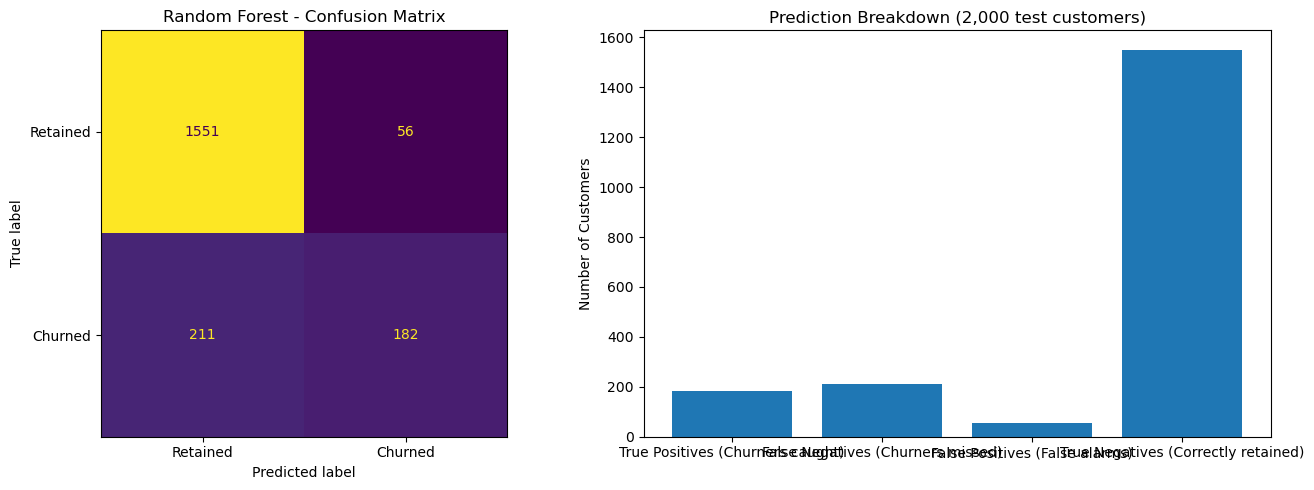

Churners correctly flagged:  182
Churners missed:             211  (cost: $51,273 in replacement)
False alarms:                56
Correctly retained:          1551


In [12]:
rf_model = models['Random Forest']
y_pred_rf = predictions['Random Forest']
cm = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest - Confusion Matrix')

tn, fp, fn, tp = cm.ravel()
categories = ['True Positives (Churners caught)',
               'False Negatives (Churners missed)',
               'False Positives (False alarms)',
               'True Negatives (Correctly retained)']
axes[1].bar(categories, [tp, fn, fp, tn])
axes[1].set_title('Prediction Breakdown (2,000 test customers)')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(os.path.join(project_visuals_dir, 'confusion_matrix.png'))
plt.show()

acquisition_cost = 243
print(f"Churners correctly flagged:  {tp}")
print(f"Churners missed:             {fn}  (cost: ${fn * acquisition_cost:,} in replacement)")
print(f"False alarms:                {fp}")
print(f"Correctly retained:          {tn}")

Random Forest catches 182 out of 393 churners in the test set, a 46% catch rate. On a 10,000 customer base that saves approximately $106,722 in replacement costs per year at current churn rates.

The 211 missed churners represent the model's current ceiling without further tuning. The path to improvement is either SMOTE to address class imbalance or lowering the decision threshold from 0.5 to prioritize recall over precision.

## 7. Feature Importance

The Random Forest model assigns importance scores to each feature based on how much they reduce impurity across all decision trees.


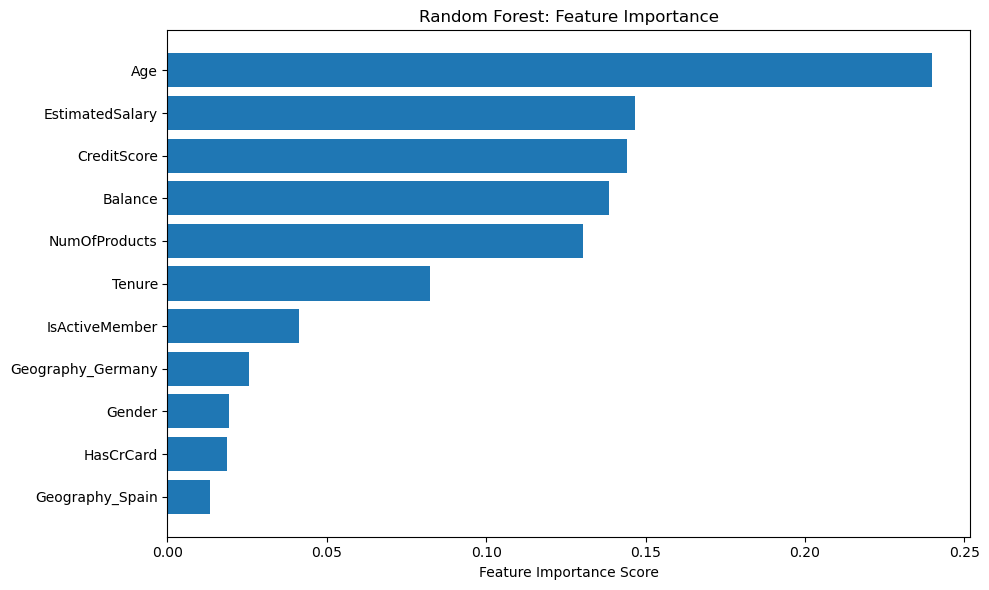

Top 5 features:
  1. Age                    0.2398
  2. EstimatedSalary        0.1466
  3. CreditScore            0.1442
  4. Balance                0.1386
  5. NumOfProducts          0.1303


In [13]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [features[i] for i in indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(features)), importances[indices])
ax.set_yticks(range(len(features)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance Score')
ax.set_title('Random Forest: Feature Importance')

plt.tight_layout()
plt.savefig(os.path.join(project_visuals_dir, 'feature_importance.png'))
plt.show()

print("Top 5 features:")
for i in range(5):
    print(f"  {i+1}. {names[i]:<22} {importances[indices[i]]:.4f}")

- Age is the dominant predictor by a significant margin, validating the 46-60 age band finding from EDA
- Balance and EstimatedSalary rank highly, confirming that financial profile matters beyond credit score
- IsActiveMember ranks strongly, validating the weight placed on inactivity in the SQL risk score
- CreditScore ranks lower than expected, consistent with the SQL Q1 finding that churn rate barely moves across credit tiers
- Geography (Germany) has meaningful importance but lower than behavioral signals, confirming that what customers do matters more than where they are


## 8. Feature Engineering

Hypothesis: engineered features that capture behavioral patterns more explicitly might improve model performance beyond 86.7%.

Features added:
- BalanceZero: binary flag for zero-balance accounts (behavior, not amount)
- AgeGroup: age buckets matching the retention team's segmentation logic
- BalanceToSalaryRatio: relative financial engagement vs absolute balance
- ProductUsage: interaction term (NumOfProducts x IsActiveMember)
- TenureGroup: tenure buckets to test whether lifecycle stage matters
- Male_Germany / Male_Spain: interaction terms to test gender-geography effects


In [14]:
df_fe = pd.read_csv(r'C:\Users\virin\Desktop\Projects\churn_prediction_model\Churn_Modelling.csv')

df_fe['BalanceZero']          = (df_fe['Balance'] == 0).astype(int)
df_fe['BalanceToSalaryRatio'] = df_fe['Balance'] / df_fe['EstimatedSalary']
df_fe['ProductUsage']         = df_fe['NumOfProducts'] * df_fe['IsActiveMember']

df_fe['AgeGroup']    = pd.cut(df_fe['Age'],
    bins=[18, 25, 35, 45, 55, 65, 75, 85, 95],
    labels=['18-25','26-35','36-45','46-55','56-65','66-75','76-85','86-95'])
df_fe['TenureGroup'] = pd.cut(df_fe['Tenure'],
    bins=[0, 2, 5, 7, 10],
    labels=['0-2','3-5','6-7','8-10'])

label_encoder = LabelEncoder()
df_fe['Gender'] = label_encoder.fit_transform(df_fe['Gender'])
df_fe = pd.get_dummies(df_fe, columns=['Geography'], drop_first=True)
df_fe['Male_Germany'] = df_fe['Gender'] * df_fe['Geography_Germany']
df_fe['Male_Spain']   = df_fe['Gender'] * df_fe['Geography_Spain']
df_fe = pd.get_dummies(df_fe, columns=['AgeGroup', 'TenureGroup'], drop_first=True)

fe_features = (
    ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard',
     'IsActiveMember','EstimatedSalary','Geography_Germany','Geography_Spain',
     'BalanceZero','BalanceToSalaryRatio','ProductUsage','Male_Germany','Male_Spain']
    + [c for c in df_fe.columns if 'AgeGroup_' in c or 'TenureGroup_' in c]
)

X_fe = df_fe[fe_features]
y_fe = df_fe['Exited']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42)

scaler_fe = StandardScaler()
X_train_fe = scaler_fe.fit_transform(X_train_fe)
X_test_fe  = scaler_fe.transform(X_test_fe)

rf_fe = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = rf_fe.predict(X_test_fe)

acc_baseline = accuracy_score(y_test, y_pred_rf)
acc_fe       = accuracy_score(y_test_fe, y_pred_fe)
rec_baseline = classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
rec_fe       = classification_report(y_test_fe, y_pred_fe, output_dict=True, zero_division=0)['1']['recall']

comparison = pd.DataFrame({
    'Version':        ['Baseline (11 features)', 'Feature Engineered (26 features)'],
    'Accuracy':       [f'{acc_baseline:.4f}', f'{acc_fe:.4f}'],
    'Recall (Churn)': [f'{rec_baseline:.2f}',  f'{rec_fe:.2f}'],
    'Feature Count':  [11, len(fe_features)]
})
print(comparison.to_string(index=False))

                         Version Accuracy Recall (Churn)  Feature Count
          Baseline (11 features)   0.8665           0.46             11
Feature Engineered (26 features)   0.8650           0.47             25


Adding 15 engineered features produced no meaningful improvement in either accuracy or churn recall. Accuracy moved from 86.65% to 86.50%, essentially flat.

This is a useful finding, not a failure. It tells us the original 11 behavioral features already capture most of the available signal and the model is not under-fitting. The path to improvement is better handling of class imbalance (SMOTE) or decision threshold tuning, not more features.


## 9. Business Recommendations

---

### 1. Use the SQL risk score as the immediate retention list
The rules-based composite risk score (built in churn_prediction.sql) identified a Critical band churning at 45.5% vs a 20.4% baseline. Before the ML model goes to production, that SQL output is a deployable, explainable list the retention team can act on without any IT dependency.

---

### 2. Focus Germany before any other market
Germany churns at 32.4% vs roughly 16% in France and Spain, representing $97.9M in deposits at risk. German female customers aged 46-60 show the highest churn rate of any segment (76% in the cross-sell analysis). A Germany-specific retention pilot before scaling globally is the highest-ROI use of budget.

---

### 3. Cross-sell as a retention strategy
Single-product customers churn at 28%. Two-product customers churn at 8%. A targeted cross-sell campaign for high-balance single-product customers (identified in SQL Q5) reduces churn risk while growing revenue simultaneously. The 785 high-value inactive customers flagged in Q5 are the starting list.

---

### 4. Next modeling step: decision threshold tuning
The current model catches 46% of churners at the default 0.5 decision threshold. Lowering the threshold to 0.3 would increase recall at the cost of more false positives. Given that false negatives cost $243 each and false positives cost only a retention offer, the economics favor a lower threshold. Recommended next step: plot the precision-recall curve and find the threshold that minimizes total business cost.

---

*Full SQL analysis, cohort segmentation, and business impact sizing available in churn_prediction.sql in this repository.*
